__Задача 1.__ 

Построить численно общее решение задачи Коши при произвольных начальных условиях:

$$
y^{\prime \prime}-\left(10+x^2\right) y=x e^{-x}, \quad 0<x<10
$$

$$
y(0)=\alpha, \quad y^{\prime}(0)=\beta
$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
# явный эйлер
def solve(a, b, T, dt):
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    y = np.empty(num_steps+1)
    y[0] = a
    y[1] = a + b*dt + 10*a*(dt**2)/2

    for k in range(1, num_steps):
        y[k+1] = dt**2 * (tt[k]*np.exp(-tt[k]) + (10 + (tt[k])**2)*y[k]) + 2*y[k] - y[k-1]
    return tt, y

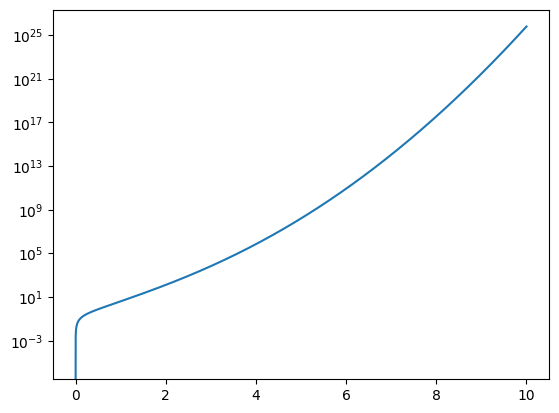

In [13]:
tt, y = solve(0, 1, 10, 0.00001)
plt.semilogy(tt, y)

In [15]:
# неявный эйлер
def solve2(a, b, T, dt):
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    y = np.empty(num_steps+1)
    y[0] = a
    y[1] = a + b*dt + 10*a*(dt**2)/2

    for k in range(1, num_steps):
        y[k+1] = ((dt**2) * tt[k+1]*np.exp(-tt[k+1]) + 2*y[k] - y[k-1]) / (1 - (dt**2)*(10 + (tt[k+1])**2))
    return tt, y

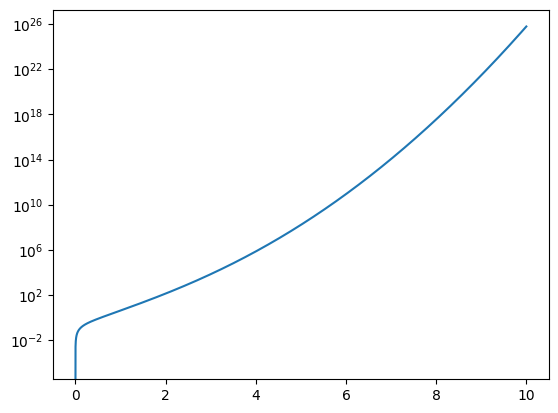

In [17]:
tt, y = solve(0, 1, 10, 0.0001)
plt.semilogy(tt, y)

__Задача 2.__ 

Получите численные решения следующей нелинейной краевой задачи при различных параметрах:

$$
\begin{aligned}
& y^{\prime \prime}+\sin y=0, \quad 0<x \leq x_k, \\
& y(0)=0, \quad y\left(x_k\right)=\pi, \\
& x_k=0.5 ;\; 1 ;\; 2 ;\; 4 ;\; 6 .
\end{aligned}
$$

In [ ]:
def a(a, xk, T, dt):
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    y = np.empty(num_steps+1)
    y[0] = a

    for k in range(num_steps):
        y[k+1] = y[k] + dt * ((y[k])**2 * np.cos(np.pi * tt[k]/xk) + 1)
    return tt, y

def b(a, xk, T, dt):
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    y = np.empty(num_steps+1)
    y[0] = a

    for k in range(num_steps):
        y[k+1] = y[k] + dt * ((y[k])**2 * np.cos(np.pi * tt[k]/xk) + 1)
    return tt, y

In [ ]:
# метод Ньютона
def solve3(xk, dt):
    num_steps = int(xk/dt)
    tt = np.arange(num_steps+1)*dt
    y = np.empty(num_steps+1)
    y[0] = 0
    y[num_steps] = np.pi
    y0 = tt * np.pi/xk

    for k in range(1, num_steps):
        
    return tt, y

__Задача 3.__

Решите следующее УРЧП __любым численным способом__. Визуализируйте полученное решение. Есть ли сходимость?
$$
\begin{aligned}
& \frac{\partial^2 u}{\partial x^2}+ \frac{\partial^2 u}{\partial y^2}+x^2\cdot\frac{\partial u}{\partial x}+\frac{\partial u}{\partial y}=f(x, y), \quad 0 \leq x \leq 1, \quad 0 \leq y \leq 1, \\
& f(x, y)=-32(x(1-x)+y(1-y)),\left.\quad u\right|_{x, y \in \Gamma}=0
\end{aligned}
$$